Charly Rapin and Zheng Hong Gan

# Libraries

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# Dataset and Goal

The dataset : Spotify Tracks Dataset  
Link: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset  
The goal is to identify what make a song popular using the above dataset. This will allow artits to make prediction on whether a song will become popular or not. It can also be used to understand what make songs globally likeable and generate songs that meets the same criteria to increase the likelyhood of a song becoming popular.  
The dataset has the following 20 features:


* track_id
* artists
* album_name
* track_name
* popularity
* duration_ms
* explicit
* danceability
* energy
* key
* loudness
* mode
* speechiness
* acousticness
* instrumentalness
* liveness
* valence
* tempo
* time_signature
* track_genre

This includes a mix of categorical and numerical data.  
The target variable is the popularity feature. This feature will be predicted using k-Nearest Neighbors and Random Forest Regression .


# Exploratory Data Analysis



In [35]:
df = pd.read_csv('dataset.csv')

Let's first list a few observations to get a better understanding of the dataset

In [36]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


Before plotting graphs, let's look for any missing values

In [37]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

There is one artist, one album name and one track name that is missing. But since we are only predicting popularity of a song given its characteristic, we will not take into account the artist, album name, or track name. Since we will remove the following features, nothing needs to be done regarding the missing values.

Let's now plot some features to get a better understanding of how it impacts the popularity of songs.  
Do to the large amount of observations, it can overwhelm graphs very rapidly.   
Lets take a random subset of the dataset to make the inital observations.


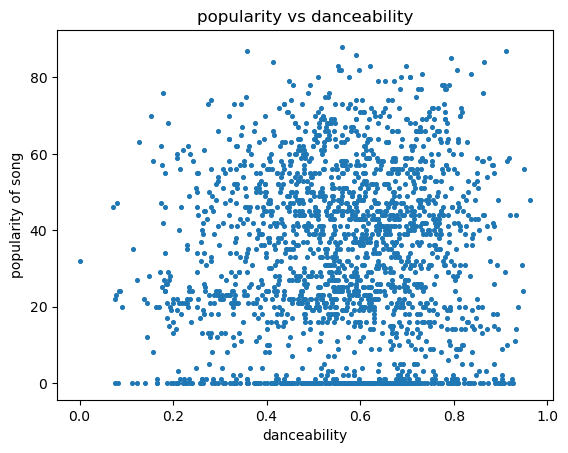

In [38]:
df_subset = df.sample(n=2000, random_state=1) # take a random subset of rows from the inital dataset

plt.scatter(df_subset['danceability'],df_subset['popularity'], s=7)
plt.xlabel("danceability")
plt.ylabel("popularity of song")
plt.title("popularity vs danceability")
plt.show()

There does not seems to be a clear relationship between danceability and popularity

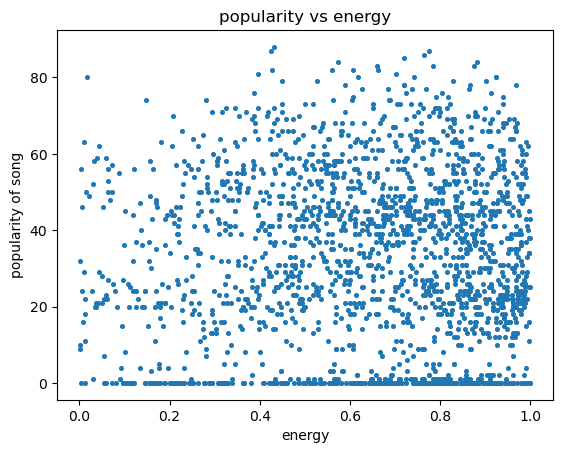

In [39]:

plt.scatter(df_subset['energy'],df_subset['popularity'], s=7)
plt.xlabel("energy")
plt.ylabel("popularity of song")
plt.title("popularity vs energy")
plt.show()

There also does not seems to be a clear pattern between popularity and the overall energy of the song. Let look into the relationship between popularity and the genre of songs

In [40]:
#lets looks at the amount of genre that is defined in the dataset
all_genre    = df['track_genre'].unique()
amount_genre = len(all_genre)
print("List of all the genre:", all_genre, " total amount of genre: ", amount_genre)


List of all the genre: ['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient' 'anime'
 'black-metal' 'bluegrass' 'blues' 'brazil' 'breakbeat' 'british'
 'cantopop' 'chicago-house' 'children' 'chill' 'classical' 'club' 'comedy'
 'country' 'dance' 'dancehall' 'death-metal' 'deep-house' 'detroit-techno'
 'disco' 'disney' 'drum-and-bass' 'dub' 'dubstep' 'edm' 'electro'
 'electronic' 'emo' 'folk' 'forro' 'french' 'funk' 'garage' 'german'
 'gospel' 'goth' 'grindcore' 'groove' 'grunge' 'guitar' 'happy'
 'hard-rock' 'hardcore' 'hardstyle' 'heavy-metal' 'hip-hop' 'honky-tonk'
 'house' 'idm' 'indian' 'indie-pop' 'indie' 'industrial' 'iranian'
 'j-dance' 'j-idol' 'j-pop' 'j-rock' 'jazz' 'k-pop' 'kids' 'latin'
 'latino' 'malay' 'mandopop' 'metal' 'metalcore' 'minimal-techno' 'mpb'
 'new-age' 'opera' 'pagode' 'party' 'piano' 'pop-film' 'pop' 'power-pop'
 'progressive-house' 'psych-rock' 'punk-rock' 'punk' 'r-n-b' 'reggae'
 'reggaeton' 'rock-n-roll' 'rock' 'rockabilly' 'romance' 'sad' 'salsa'
 's

Due to the large amount of genre (114). Let take a look at the 10 popular genre.

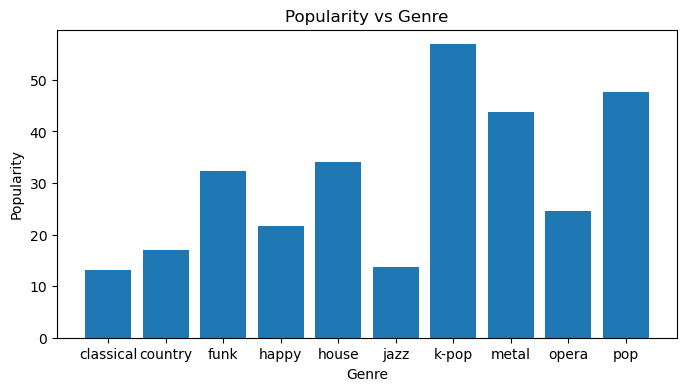

In [41]:
limited_genre       = df[df["track_genre"].isin(['funk','k-pop','jazz','house','pop','classical','happy','opera','metal','country'])] #only looks at the following genres
popularity_by_genre = limited_genre.groupby("track_genre")["popularity"].mean()
plt.figure(figsize  =(8,4)) # increase size of graph to prevent labels overlap
plt.bar(popularity_by_genre.index,popularity_by_genre.values )
plt.xlabel("Genre")
plt.ylabel("Popularity")
plt.title("Popularity vs Genre")
plt.show()

Songs from the k-pop and pop genre seems to be more popular then other categories

# Cleaning Dataset

Before seperating the dataset into training and testing dataset, let first clean the dataset.  
This includes removing unnecessary features, converting categorical data into numerical values and scaling feature to prevent feature with large value from having a bigger influence from feature with a smaller range of values.  
We are interested in the characteristic of songs which result in popularity. The name of the artist, album name, track number and track id are features which are not related to the actual song. Therefore they are removed from the features used to make the models. There is also the possibility that the same song is included more than once (released once as a single and once in an album). Therefore, we will also remove any duplicate songs.

In [42]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates(subset=["track_name", "artists"], keep="first")
df_clean = df_clean.drop(['album_name','track_name', 'artists','track_id'], axis = 1)

Next, lets convert categorical data into numerical data.
The two feature that needs to be converted is the explicit and the track_genre.

In [ ]:
df_clean['explicit'] = df_clean['explicit'].astype(int)


To convert the track genre into numerical data. We will use OneHotEncoder. But since this will need to first look at the data. We first need to create a training and testing data set to prevent from getting insight into the testing data. This also applies for when scalling the data.  

# Training and Testing Split

In [44]:
feature_used_for_prediction = ['duration_ms','explicit','danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo','time_signature','track_genre']
X = df_clean[feature_used_for_prediction]
Y = df_clean['popularity']
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X, Y, random_state = 1, test_size = 0.25)

Now that the data has been seperated into explicit training and testing set, we can now convert the track genre from categorical to numerical values.

In [45]:
encoder = OneHotEncoder(
  handle_unknown="error")
Xtrain_track_genre_encoded     = encoder.fit_transform(Xtrain[['track_genre']]) # train and fit on the training data
Xtest_track_genre_encoded      = encoder.transform(Xtest[['track_genre']])
x_train_track_genre_encoded_df = pd.DataFrame(Xtrain_track_genre_encoded.toarray(), columns=encoder.get_feature_names_out(), index = Xtrain.index )
x_test_track_genre_encoded_df  = pd.DataFrame(Xtest_track_genre_encoded.toarray(), columns=encoder.get_feature_names_out(), index = Xtest.index)
Xtrain_encoded_df              = Xtrain.copy()
Xtest_encoded_df               = Xtest.copy()  # copy to prevent changing the Xtrain and Xtest dataset in case needed later down the road
Xtrain_encoded_df              = pd.concat([Xtrain_encoded_df, x_train_track_genre_encoded_df], axis = 1).drop('track_genre', axis = 1)
Xtest_encoded_df               = pd.concat([Xtest_encoded_df, x_test_track_genre_encoded_df], axis = 1).drop('track_genre', axis = 1)

We can now focus on scaling the features to prevent a feature from having more influences then other features with smaller values.

In [46]:
scaler              = StandardScaler()
Xtrain_scaled_df    = Xtrain_encoded_df.copy()
Xtest_scaled_df     = Xtest_encoded_df.copy()
Xtrain_scaled_array = scaler.fit_transform(Xtrain_scaled_df)
Xtest_scaled_array  = scaler.transform(Xtest_scaled_df)
Xtrain_scaled_df    = pd.DataFrame(Xtrain_scaled_array, columns = scaler.get_feature_names_out(), index = Xtrain.index)
Xtest_scaled_df     = pd.DataFrame(Xtest_scaled_array, columns  = scaler.get_feature_names_out(), index = Xtest.index)

We now have cleaned dataset that has been seperated into training and testing sets and that has been scaled. We are ready to create models and make predictions.

# Train and Tune Models

Model one: k-Nearest Neighbors with hyperparameter tuning

In [47]:
results = []
#k value to test to find the best k value
for i in range(5,50):
  k_neighbord = KNeighborsRegressor(n_neighbors = i)
  results.append(cross_val_score(k_neighbord, Xtrain_scaled_df, Ytrain, cv = 4).mean())

#display the best k
best_k = results.index(max(results))
print(best_k)

# set the model with the inital hyperparameter that was find in the previous setp
k_neighbord = KNeighborsRegressor(n_neighbors = best_k)
#train the model
k_neighbord.fit(Xtrain_scaled_df, Ytrain)
# predict the model, using the newly made model
y_pred = k_neighbord.predict(Xtest_scaled_df)
y_train_pred = k_neighbord.predict(Xtrain_scaled_df)


39


Model performance

R^2 score:  0.39845596878098644
Training R^2 score:  0.44195218661216673
Root mean squared error:  15.12875025282394


Text(0, 0.5, 'Predicted popularity')

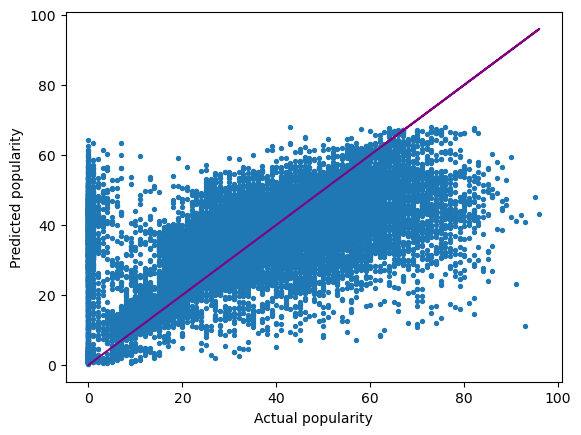

In [48]:
print("R^2 score: ", r2_score(Ytest, y_pred))
print("Training R^2 score: ", r2_score(Ytrain, y_train_pred))
print("Root mean squared error: ", root_mean_squared_error(Ytest, y_pred))
plt.scatter(Ytest,y_pred,s=8)
plt.plot(Ytest,Ytest,c='purple')
plt.xlabel("Actual popularity")
plt.ylabel("Predicted popularity")

This is a very interesting result. The model explains 40% of the total variance in the data, but 60% remains unexplained. Whether a song becomes popular or not is impacted by many features, some of which are not included in the dataset. For example, the budget used to advertise a song is not taken into account, the artist is not taken into account(popular artists' songs will be more popular even if the song does not have the quality of a popular song). This explains why it is difficult to predict a song popularity just on the characteristic of the song itself as a result of the number of hidden features that needs to be taken into account and thus explains the 60% variabilty that is not taken into account by the model. Another interesting observation is that the model is very off when predicting songs that have a popularity of 0. This is because the dataset calculated popularity based on the amount of time it was listened. But songs that were listened to a lot in the past will have a lower score then song that are listened to the same amount of time more recently. Thus, it is possible for a song to have the characteristic of a popular song but as a lower overall popularity due to the fact that it is no longer trending.  
Let's now take a look if Random Forest Regression results in better performance.

Model two: Random Forest Regression

In [49]:
from sklearn.ensemble import RandomForestRegressor

In [50]:
print("Xtrain shape:", Xtrain.shape)
print("Xtest shape:", Xtest.shape)
print("Ytrain shape:", Ytrain.shape)
print("Ytest shape:", Ytest.shape)

Xtrain shape: (61008, 15)
Xtest shape: (20336, 15)
Ytrain shape: (61008,)
Ytest shape: (20336,)


In [51]:
Xtrain.columns

Index(['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [52]:
Xtrain_encoded_df.shape, Xtest_encoded_df.shape

((61008, 127), (20336, 127))

In [53]:
Xtrain_encoded_df.columns

Index(['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness',
       ...
       'track_genre_spanish', 'track_genre_study', 'track_genre_swedish',
       'track_genre_synth-pop', 'track_genre_tango', 'track_genre_techno',
       'track_genre_trance', 'track_genre_trip-hop', 'track_genre_turkish',
       'track_genre_world-music'],
      dtype='object', length=127)

In [54]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=1,
    n_jobs=-1
)

rf_model.fit(Xtrain_encoded_df, Ytrain)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
# prediction
rf_train_pred = rf_model.predict(Xtrain_encoded_df)
rf_test_pred = rf_model.predict(Xtest_encoded_df)

Model performance

In [56]:

print("Random Forest Training R^2:", r2_score(Ytrain, rf_train_pred))
print("Random Forest Test R^2:", r2_score(Ytest, rf_test_pred))

print("Random Forest Training RMSE:", root_mean_squared_error(Ytrain, rf_train_pred))
print("Random Forest Test RMSE:", root_mean_squared_error(Ytest, rf_test_pred))

Random Forest Training R^2: 0.9145442025186514
Random Forest Test R^2: 0.3951056565263519
Random Forest Training RMSE: 5.675863669798833
Random Forest Test RMSE: 15.17082170258742


The performance of the original Random Forest model showed high R² on the training data set while low R² on the test set, meaning that there is some overfitting to the training data. Tuning of hyperparameters will help us control the complexity of the model.

## Random Forest Hyperparameter Tuning

Our first Random Forest model exhibited overfitting behavior. We will experiment with different max_depth and min_samples_leaf values to reduce the complexity of our model.

In [57]:
depths = [10, 15, 20, 25]
results = []

for depth in depths:
    model = RandomForestRegressor(
        n_estimators=50,
        max_depth=depth,
        min_samples_leaf=2,
        random_state=1,
        n_jobs=-1
    )
    
    model.fit(Xtrain_encoded_df, Ytrain)
    
    train_pred = model.predict(Xtrain_encoded_df)
    test_pred = model.predict(Xtest_encoded_df)
    
    train_r2 = r2_score(Ytrain, train_pred)
    test_r2 = r2_score(Ytest, test_pred)
    test_rmse = root_mean_squared_error(Ytest, test_pred)
    
    results.append([depth, train_r2, test_r2, test_rmse])

tuning_results = pd.DataFrame(
    results,
    columns=["Max Depth", "Train R²", "Test R²", "Test RMSE"]
)

tuning_results

,Max Depth,Train R²,Test R²,Test RMSE
0,10,0.232389,0.221186,17.214173
1,15,0.308406,0.270428,16.661089
2,20,0.373629,0.303542,16.278589
3,25,0.437060,0.330538,15.959978


From the tuning, it is clear that the increase of max_depth leads to better test scores. However, all models examined are not as good as the initial Random Forest model. Hence, we need to try other values of tree depth and min_samples_leaf.

In [58]:
depths = [30, 40, None]
leaf_sizes = [1, 2, 4]

results_2 = []

for depth in depths:
    for leaf in leaf_sizes:
        model = RandomForestRegressor(
            n_estimators=50,
            max_depth=depth,
            min_samples_leaf=leaf,
            random_state=1,
            n_jobs=-1
        )

        model.fit(Xtrain_encoded_df, Ytrain)

        train_pred = model.predict(Xtrain_encoded_df)
        test_pred = model.predict(Xtest_encoded_df)

        train_r2 = r2_score(Ytrain, train_pred)
        test_r2 = r2_score(Ytest, test_pred)
        test_rmse = root_mean_squared_error(Ytest, test_pred)

        results_2.append(
            [depth, leaf, train_r2, test_r2, test_rmse]
        )

tuning_results_2 = pd.DataFrame(
    results_2,
    columns=[
        "Max Depth",
        "Min Samples Leaf",
        "Train R²",
        "Test R²",
        "Test RMSE"
    ]
)

tuning_results_2

,Max Depth,Min Samples Leaf,Train R²,Test R²,Test RMSE
0,30.0,1,0.504656,0.349552,15.731700
1,30.0,2,0.493382,0.350590,15.719139
2,30.0,4,0.470333,0.350720,15.717574
3,40.0,1,0.594868,0.372303,15.454119
4,40.0,2,0.577978,0.372899,15.446780
5,40.0,4,0.544164,0.373725,15.436606
6,NaN,1,0.910706,0.389317,15.243241
7,NaN,2,0.870736,0.391842,15.211695
8,NaN,4,0.784702,0.395272,15.168732


from the latest tuning results, the increase in the parameter `max_depth` helped to improve test performance. The optimal combination is without any maximum depth (`max_depth=None`) and `min_samples_leaf=4`. The value of the test R² for this Random Forest model is about 0.399 and the test RMSE is 15.136. This Random Forest model outperformed the basic Random Forest on test performance and minimized the difference between training and testing performance.

In [59]:
rf_final = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=4,
    random_state=1,
    n_jobs=-1
)

rf_final.fit(Xtrain_encoded_df, Ytrain)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
rf_final_train_pred = rf_final.predict(Xtrain_encoded_df)
rf_final_test_pred = rf_final.predict(Xtest_encoded_df)

print("Final Random Forest Training R^2:", r2_score(Ytrain, rf_final_train_pred))
print("Final Random Forest Test R^2:", r2_score(Ytest, rf_final_test_pred))
print("Final Random Forest Training RMSE:", root_mean_squared_error(Ytrain, rf_final_train_pred))
print("Final Random Forest Test RMSE:", root_mean_squared_error(Ytest, rf_final_test_pred))

Final Random Forest Training R^2: 0.7875461221976143
Final Random Forest Test R^2: 0.4009017267888675
Final Random Forest Training RMSE: 8.949391785196276
Final Random Forest Test RMSE: 15.097963687961558


## Final Random Forest Performance

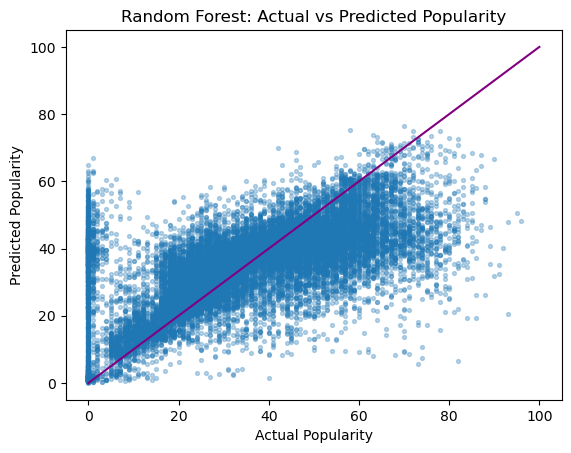

In [61]:
plt.scatter(Ytest, rf_final_test_pred, s=8, alpha=0.3)

plt.plot([0, 100], [0, 100], 'purple')

plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Random Forest: Actual vs Predicted Popularity")

plt.show()

## Random Forest Feature Importance

One way we can evaluate the relative importance of features in the final Random Forest model is by determining what helped build the predictions.

In [62]:
feature_importance = pd.Series(
    rf_final.feature_importances_,
    index=Xtrain_encoded_df.columns
).sort_values(ascending=False)

feature_importance.head(15)

instrumentalness             0.066492
duration_ms                  0.054915
loudness                     0.053660
energy                       0.052887
acousticness                 0.052353
speechiness                  0.050108
valence                      0.049245
danceability                 0.048487
tempo                        0.045357
liveness                     0.043621
track_genre_iranian          0.040663
track_genre_romance          0.034272
key                          0.022121
track_genre_kids             0.018192
track_genre_chicago-house    0.017134
dtype: float64

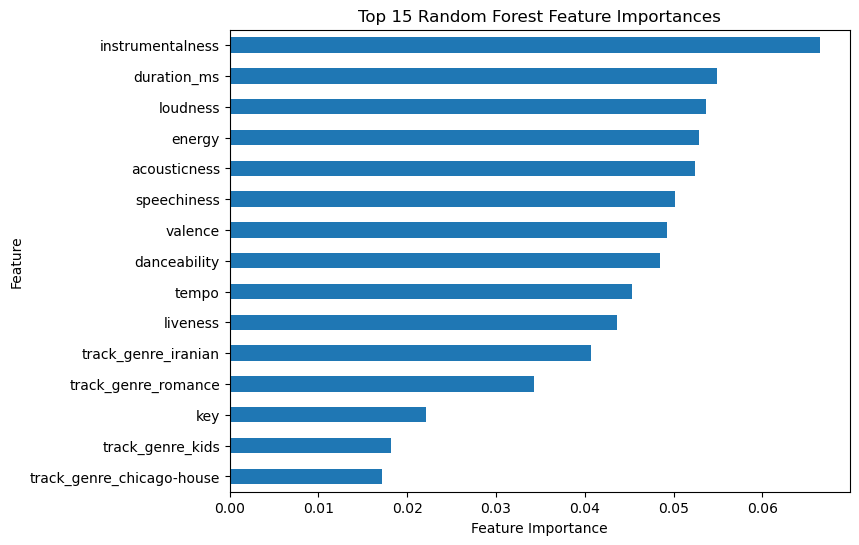

In [63]:
top_features = feature_importance.head(15).sort_values()

plt.figure(figsize=(8, 6))
top_features.plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")

plt.show()

## Model Comparison

In [64]:
model_comparison = pd.DataFrame({
    "Model": ["KNN", "Random Forest"],
    "Training R²": [
        r2_score(Ytrain, y_train_pred),
        r2_score(Ytrain, rf_final_train_pred)
    ],
    "Test R²": [
        r2_score(Ytest, y_pred),
        r2_score(Ytest, rf_final_test_pred)
    ],
    "Test RMSE": [
        root_mean_squared_error(Ytest, y_pred),
        root_mean_squared_error(Ytest, rf_final_test_pred)
    ]
})

model_comparison

,Model,Training R²,Test R²,Test RMSE
0,KNN,0.441952,0.398456,15.128750
1,Random Forest,0.787546,0.400902,15.097964


# Results and Conclusion

Both KNN and Random Forest were able to predict Spotify song popularity to some extent, although neither model achieved highly accurate results. The tuned Random Forest performed slightly better on the test data, with a test R² of approximately 0.401 and an RMSE of 15.098, compared with a test R² of approximately 0.398 and an RMSE of 15.129 for KNN. However, the difference in test performance between the two models was very small. KNN had a much smaller difference between its training and testing R², indicating less overfitting and more consistent performance between the training and test sets.

The Random Forest exhibited clear signs of overfitting. However, tuning of `max_depth` and `min_samples_leaf` parameters led to closing the gap between the training and testing scores, even though the latter increased insignificantly. The feature importance analysis revealed that there is no single feature dominating the prediction process. Instrumentalness, duration, loudness, energy and acousticness are the most important features in terms of importance.

Another reason why the model has poor predictive power can be the fact that popularity in Spotify depends not only on the characteristics of music used in this study. Popularity in Spotify depends on the number of streams and when they were made – these variables are not included in our model as the audio characteristics we use. So, two tracks with similar audio characteristics may have significantly different popularity.

In conclusion, it can be said that there is a certain amount of information in audio characteristics and genres that can be used in order to predict the popularity of tracks. But they are not enough in order to correctly predict it.